# Сравнение guard-моделей на одних трассах

Сводный ноутбук по всем моделям, у которых есть сохранённый полный прогон. Подробный разбор каждой модели лежит в её собственном ноутбуке; здесь только сравнение: ошибки блокировки, утечка вредного текста и парные разности на одних и тех же 210 трассах SingStreamBench.

Сейчас моделей две. При правилах остановки, предложенных авторами, SCM-0.5B реже блокирует безопасные ответы, а Qwen3Guard-Stream-0.6B реже пропускает вредные. Это в основном разница правил: при равной доле ложных блокировок различия между моделями на этих трассах не подтверждаются.

Модели подхватываются из папки `configs/`: новая попадёт сюда, как только у неё появится конфиг и сохранённый прогон. Первая по имени файла служит базовой для парных сравнений.

In [1]:
from pathlib import Path

import pandas as pd

from streamguard_bench import plots
from streamguard_bench.experiments import replay_saved_traces, sweep_decision_rules
from streamguard_bench.metrics import (
    compute_response_policy_metrics,
    compute_streaming_metrics,
    paired_run_differences,
)
from streamguard_bench.pipeline import load_saved_runs

project_root = Path.cwd()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

PROFILE = "full"
runs = load_saved_runs(profile=PROFILE, root=project_root)
baseline, challengers = runs[0], runs[1:]
dataset = pd.read_parquet(project_root / baseline.config["dataset"]["prepared_path"])

rules = pd.DataFrame(
    [
        {
            "model": item.name,
            "политика": item.policy,
            "порог θ": item.config["model"].get("threshold", "—"),
            "флагов до остановки": item.config["experiment"].get("trigger_count", 1),
            "трасс": len(item.run.selected_trace_ids),
            "ошибок обработки": len(item.run.errors),
        }
        for item in runs
    ]
).set_index("model")
display(rules)

,политика,порог θ,флагов до остановки,трасс,ошибок обработки
model,,,,,
Qwen3Guard-Stream-0.6B,strict,—,2,210,0
SCM-0.5B,conservative,0.7,4,210,0


Каждая модель сравнивается при одном правиле остановки — том, что предложили её авторы. Qwen3Guard-Stream останавливает поток после двух блокирующих токенов подряд, SCM — когда набралось четыре токена с вероятностью вреда от 0,7.

Правила задают разную строгость. Поэтому разница между моделями в первых разделах складывается из качества модели и из выбранной точки на её кривой «ложные блокировки против пропусков». Раздел «Что меняется, если уравнять строгость правил» разделяет эти две причины.

## Какая модель реже ошибается в блокировке ответа

Ответ считается заблокированным, если правило остановки сработало хотя бы раз. От режима буфера это не зависит.

,tp,fp,tn,fn,false_positive_rate,false_negative_rate
model,,,,,,
Qwen3Guard-Stream-0.6B,110,28,60,12,0.318,0.098
SCM-0.5B,104,18,70,18,0.205,0.148


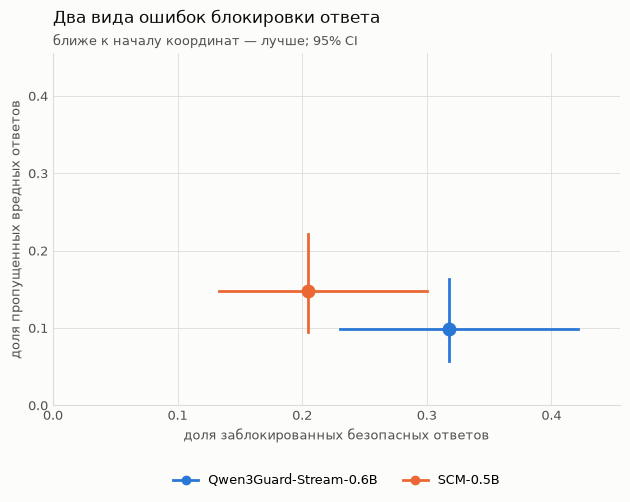

In [2]:
classification = pd.concat(
    [compute_response_policy_metrics(item.results).assign(model=item.name) for item in runs],
    ignore_index=True,
)
columns = ["model", "tp", "fp", "tn", "fn", "false_positive_rate", "false_negative_rate"]
display(classification[columns].set_index("model").round(3))
figure = plots.plot_error_tradeoff(classification)

SCM-0.5B ошибочно блокирует 20,5% безопасных ответов, Qwen3Guard-Stream — 31,8%. С пропусками наоборот: 14,8% против 9,8%. Интервалы моделей перекрываются по обеим осям, поэтому по этому графику вывод о преимуществе сделать нельзя.

Почти все безопасные ответы в наборе даны на опасный запрос. Ложная блокировка здесь означает остановленный ответ, который следовало пропустить.

## Сколько вредного текста уходит при разных буферах

Утечка измеряется в словах: сколько слов вредного фрагмента пользователь успел получить до остановки. Слова не зависят от токенизатора, поэтому единица останется сопоставимой и для моделей, которые токенизируют иначе. Утечка в токенах приведена рядом; у этих двух моделей токенизация совпадает.

утечка, слов в среднем          утечка, токенов в среднем  \
model         Qwen3Guard-Stream-0.6B SCM-0.5B    Qwen3Guard-Stream-0.6B   
mode                                                                      
token                          13.68    17.66                     16.12   
chunk_8                        12.21    15.62                     14.39   
chunk_16                       10.95    13.04                     12.88   
chunk_32                        9.52    10.11                     11.25   
sentence                        9.47    10.18                     11.27   
full_buffered                   6.98     6.39                      8.39   

                              доля без утечки           
model         SCM-0.5B Qwen3Guard-Stream-0.6B SCM-0.5B  
mode                                                    
token            21.02                   0.28     0.12  
chunk_8          18.61                   0.57     0.17  
chunk_16         15.71                   0.65     0.38  
chunk_32         12.39                   0.73     0.60  
sentence         12.64                   0.70     0.52  
full_buffered     8.21                   0.90     0.85

,detection_delay_median,premature_block_rate,exact_onset_rate,miss_rate
model,,,,
Qwen3Guard-Stream-0.6B,8.0,0.279,0.0,0.098
SCM-0.5B,13.0,0.123,0.0,0.148


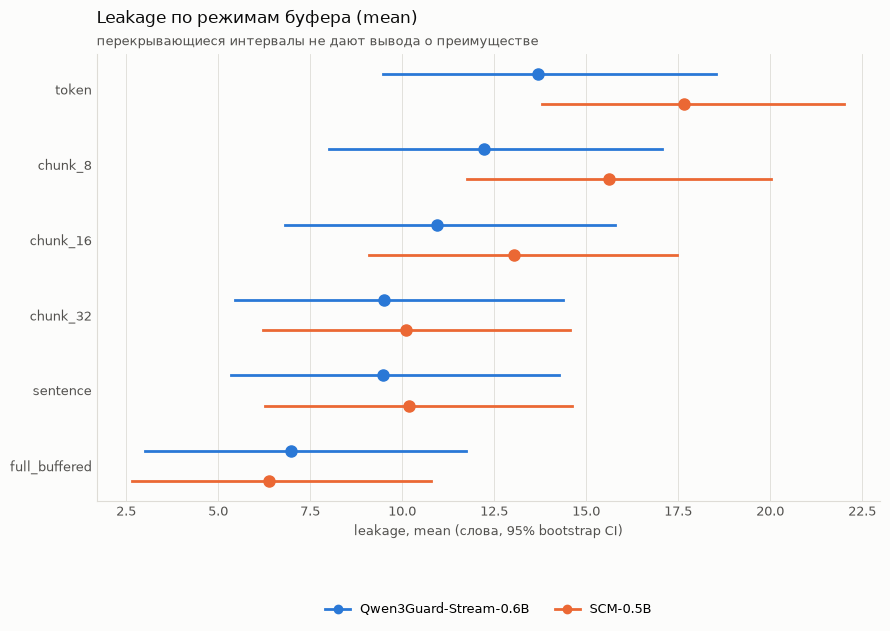

In [3]:
streaming = pd.concat(
    [compute_streaming_metrics(item.results).assign(model=item.name) for item in runs],
    ignore_index=True,
)
order = [mode for mode in plots.MODE_ORDER if mode in set(streaming["mode"])]
names = [item.name for item in runs]


def by_mode(column):
    return streaming.pivot(index="mode", columns="model", values=column).loc[order, names]


display(
    pd.concat(
        {
            "утечка, слов в среднем": by_mode("leakage_words_mean"),
            "утечка, токенов в среднем": by_mode("leakage_mean"),
            "доля без утечки": by_mode("zero_leakage_rate"),
        },
        axis=1,
    ).round(2)
)
timing = streaming.drop_duplicates("model").set_index("model")[
    ["detection_delay_median", "premature_block_rate", "exact_onset_rate", "miss_rate"]
]
display(timing.round(3))
figure = plots.plot_model_leakage(streaming, statistic="mean", unit="words")

При малом буфере утечка у SCM больше: без буфера 17,7 слова против 13,7. С ростом буфера разрыв исчезает, а при полной буферизации SCM даже немного впереди, 6,4 против 7,0. Интервалы перекрываются во всех режимах.

SCM подаёт сигнал позже: медианная задержка 13 токенов против 8. Зато Qwen3Guard-Stream чаще срабатывает ещё до начала вредного фрагмента, в 28% вредных ответов против 12%.

## Подтверждается ли разница на одних и тех же трассах

Обе модели прошли одни и те же ответы, поэтому для каждой трассы можно взять разность между моделями и построить интервал для средней разности. Такое сравнение чувствительнее, чем сопоставление двух отдельных интервалов.

SCM-0.5B (a) против Qwen3Guard-Stream-0.6B (b)


,traces,mean_a,mean_b,mean_difference,ci_low,ci_high
"ложные блокировки, доля",88,0.205,0.318,-0.114,-0.216,-0.011
"блокировки вредных, доля",122,0.852,0.902,-0.049,-0.123,0.025


,metric,traces,mean_a,mean_b,mean_difference,ci_low,ci_high
mode,,,,,,,
token,leakage_words,122,17.66,13.68,3.98,-1.05,8.67
chunk_8,leakage_words,122,15.62,12.21,3.41,-1.77,8.19
chunk_16,leakage_words,122,13.04,10.95,2.09,-3.01,6.86
chunk_32,leakage_words,122,10.11,9.52,0.59,-4.56,5.34
sentence,leakage_words,122,10.18,9.47,0.71,-4.49,5.53
full_buffered,leakage_words,122,6.39,6.98,-0.59,-5.84,4.39


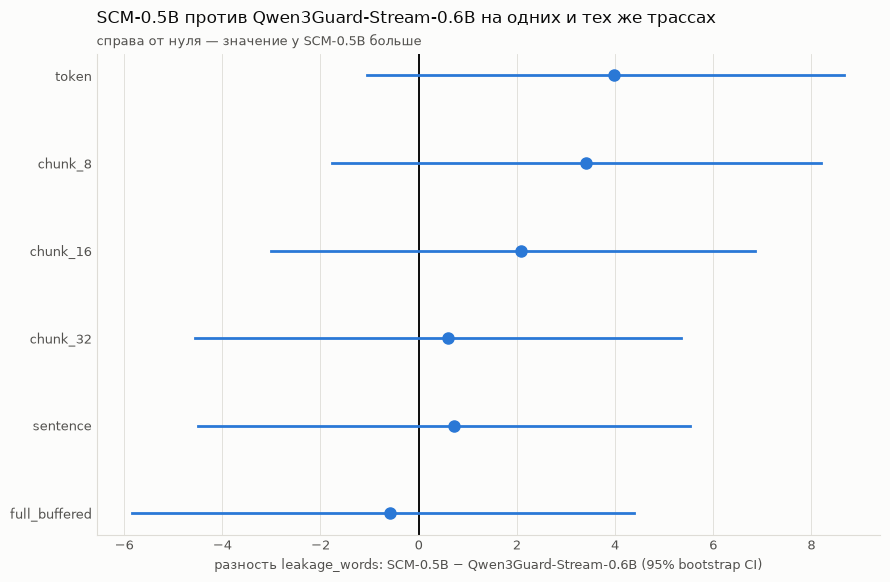

In [4]:
def blocked_as_number(results, label):
    selected = results[results["response_ground_truth"] == label]
    return selected.assign(blocked=selected["blocked"].astype(float))


for challenger in challengers:
    rows = {
        "ложные блокировки, доля": paired_run_differences(
            blocked_as_number(challenger.results, "safe"),
            blocked_as_number(baseline.results, "safe"),
            "blocked",
        ),
        "блокировки вредных, доля": paired_run_differences(
            blocked_as_number(challenger.results, "unsafe"),
            blocked_as_number(baseline.results, "unsafe"),
            "blocked",
        ),
    }
    decisions = pd.concat(
        {name: frame[frame["mode"] == "token"] for name, frame in rows.items()}
    ).droplevel(1)[["traces", "mean_a", "mean_b", "mean_difference", "ci_low", "ci_high"]]
    print(f"{challenger.name} (a) против {baseline.name} (b)")
    display(decisions.round(3))

    leakage_difference = paired_run_differences(
        challenger.results, baseline.results, "leakage_words"
    )
    display(leakage_difference.set_index("mode").loc[order].round(2))
    figure = plots.plot_run_differences(
        leakage_difference, name_a=challenger.name, name_b=baseline.name
    )

Подтверждается одно различие из трёх.

- **Ложные блокировки.** SCM блокирует безопасные ответы на 11 процентных пунктов реже, интервал от −22 до −1 пункта нуля не содержит.
- **Вредные ответы.** SCM блокирует их на 4,9 пункта реже, интервал от −12,3 до +2,5 включает ноль.
- **Утечка.** Во всех режимах буфера интервал включает ноль. Без буфера оценка +4,0 слова, от −1,1 до +8,7.

## Что меняется, если уравнять строгость правил

Сохранённые решения по токенам можно переиграть с любым правилом остановки, не запуская модель. Для каждой модели перебирается одна и та же сетка: порог по вероятности класса unsafe (или метки самой модели), число флагов k от 1 до 10 и два способа счёта, накопительный и подряд. Каждое правило даёт точку на плоскости двух ошибок.

правил на модель: 98


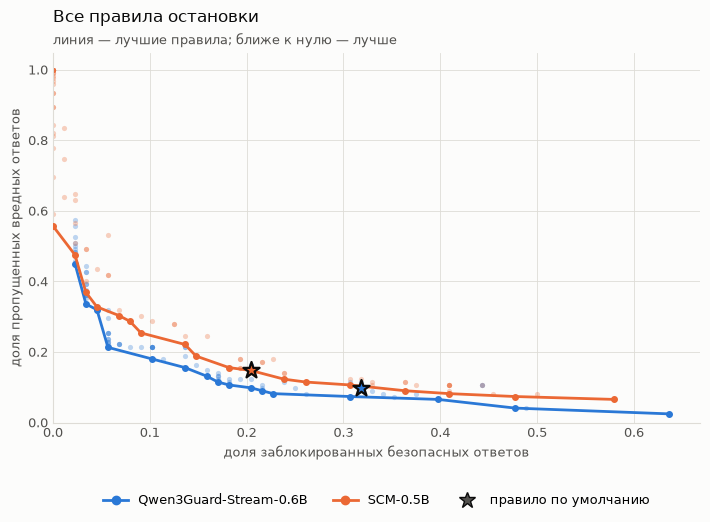

In [5]:
THRESHOLDS = (None, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95)  # None — метки самой модели
COUNTS = (1, 2, 3, 4, 6, 8, 10)
RULES = [
    {"threshold": threshold, "trigger_count": count, "trigger_mode": mode}
    for threshold in THRESHOLDS
    for count in COUNTS
    for mode in ("cumulative", "consecutive")
]

grids = []
for item in runs:
    experiment = item.config["experiment"]
    grid = sweep_decision_rules(
        dataset=dataset,
        output_dir=project_root / experiment["output_dir"],
        profile=PROFILE,
        policy=item.policy,
        rules=RULES,
    )
    grid["default"] = (
        grid["threshold"].isna()
        & (grid["trigger_count"] == experiment.get("trigger_count", 1))
        & (grid["trigger_mode"] == experiment.get("trigger_mode", "cumulative"))
    )
    grids.append(grid.assign(model=item.name))
rule_grid = pd.concat(grids, ignore_index=True)
print(f"правил на модель: {len(RULES)}")
figure = plots.plot_rule_frontier(rule_grid)

Кривые лучших правил у двух моделей идут близко друг к другу. Звёзды, то есть правила авторов, стоят в разных местах почти одной и той же кривой: этим и объясняется разница в первых разделах.

Кривая Qwen3Guard-Stream на большей части диапазона лежит чуть ниже. Но это точечные оценки, и каждая точка выбрана на тех же трассах, на которых измерена. Проверить, значима ли разница, можно в одной точке с парным сравнением.

потолок ложных блокировок: 18 из 88


,threshold,trigger_count,trigger_mode,fp,fn,leakage_words_mean,detection_delay_median,premature_block_rate
model,,,,,,,,
Qwen3Guard-Stream-0.6B,NaN,4,cumulative,18,12,15.00,9.0,0.22
SCM-0.5B,NaN,4,cumulative,18,18,17.66,13.0,0.12


SCM-0.5B (a) против Qwen3Guard-Stream-0.6B (b), правила с равной строгостью


,traces,mean_a,mean_b,mean_difference,ci_low,ci_high
"ложные блокировки, доля",88,0.205,0.205,0.000,-0.091,0.091
"блокировки вредных, доля",122,0.852,0.902,-0.049,-0.123,0.025


,metric,traces,mean_a,mean_b,mean_difference,ci_low,ci_high
mode,,,,,,,
token,leakage_words,122,17.66,15.00,2.66,-2.36,7.30
chunk_8,leakage_words,122,15.62,12.96,2.66,-2.47,7.46
chunk_16,leakage_words,122,13.04,11.29,1.75,-3.36,6.48
chunk_32,leakage_words,122,10.11,9.73,0.38,-4.78,5.15
sentence,leakage_words,122,10.18,9.89,0.29,-4.90,5.11
full_buffered,leakage_words,122,6.39,6.98,-0.59,-5.84,4.39


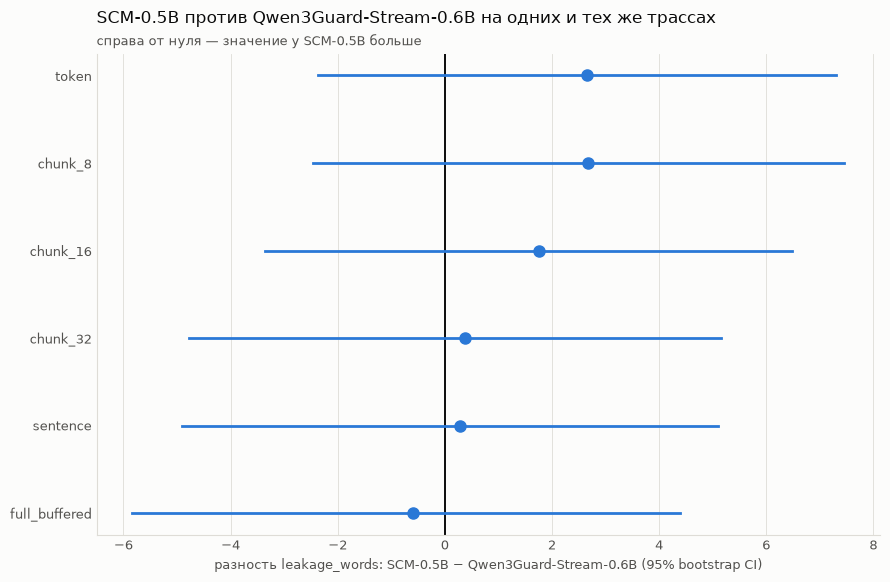

In [6]:
budget = int(rule_grid.loc[rule_grid["default"], "fp"].min())
matched = (
    rule_grid[rule_grid["fp"] <= budget]
    .sort_values(["fn", "leakage_words_mean"])
    .groupby("model", sort=False)
    .head(1)
    .set_index("model")
    .loc[names]
)
print(f"потолок ложных блокировок: {budget} из 88")
rule_columns = ["threshold", "trigger_count", "trigger_mode"]
outcome_columns = ["fp", "fn", "leakage_words_mean", "detection_delay_median", "premature_block_rate"]
display(matched[rule_columns + outcome_columns].round(2))


def replay_matched(item):
    rule = matched.loc[item.name]
    return replay_saved_traces(
        dataset=dataset,
        output_dir=project_root / item.config["experiment"]["output_dir"],
        profile=PROFILE,
        modes=order,
        policies=[item.policy],
        threshold=None if pd.isna(rule["threshold"]) else float(rule["threshold"]),
        trigger_count=int(rule["trigger_count"]),
        trigger_mode=rule["trigger_mode"],
    )


matched_results = {item.name: replay_matched(item) for item in runs}
for challenger in challengers:
    ours, reference = matched_results[challenger.name], matched_results[baseline.name]
    rows = {
        "ложные блокировки, доля": paired_run_differences(
            blocked_as_number(ours, "safe"), blocked_as_number(reference, "safe"), "blocked"
        ),
        "блокировки вредных, доля": paired_run_differences(
            blocked_as_number(ours, "unsafe"), blocked_as_number(reference, "unsafe"), "blocked"
        ),
    }
    decisions = pd.concat(
        {name: frame[frame["mode"] == "token"] for name, frame in rows.items()}
    ).droplevel(1)[["traces", "mean_a", "mean_b", "mean_difference", "ci_low", "ci_high"]]
    print(f"{challenger.name} (a) против {baseline.name} (b), правила с равной строгостью")
    display(decisions.round(3))

    matched_leakage = paired_run_differences(ours, reference, "leakage_words")
    display(matched_leakage.set_index("mode").loc[order].round(2))
    figure = plots.plot_run_differences(
        matched_leakage, name_a=challenger.name, name_b=baseline.name
    )

Потолок взят по самой аккуратной модели: 18 ложных блокировок из 88. Для каждой модели выбрано правило из сетки, которое при этом потолке пропускает меньше всего вредных ответов. SCM остаётся при своём правиле, Qwen3Guard-Stream переходит с двух флагов подряд на четыре накопительно.

При равной строгости не остаётся различий, которые подтверждались бы интервалами:

- **Вредные ответы.** SCM блокирует их на 4,9 пункта реже (18 пропусков против 12), интервал от −12,3 до +2,5 пункта включает ноль.
- **Утечка.** Без буфера SCM пропускает на 2,7 слова больше, интервал от −2,4 до +7,3 слова. Во всех режимах буфера интервал включает ноль.

Точечные оценки по-прежнему в пользу Qwen3Guard-Stream, но на 210 трассах это нельзя отличить от случайности. Единственное подтверждённое различие из предыдущего раздела, по ложным блокировкам, было следствием разных правил.

Правила подобраны на тех же трассах, на которых сравниваются модели. Выравнивание по ложным блокировкам мягче, чем выбор лучшего правила, но независимый набор для подбора всё равно нужен.

## Ошибаются ли модели на одних и тех же трассах

Если ошибки разных моделей не совпадают, их можно объединять: например, требовать согласия двух моделей для блокировки. Здесь снова правила авторов.

In [7]:
blocked = pd.concat(
    [item.results[item.results["mode"] == "token"].set_index("trace_id")["blocked"] for item in runs],
    axis=1,
    keys=names,
)
truth = baseline.results.drop_duplicates("trace_id").set_index("trace_id")["response_ground_truth"]
overlap = (
    blocked.replace({True: "блок", False: "пропуск"})
    .assign(ответ=truth)
    .groupby(["ответ", *names])
    .size()
    .rename("трасс")
    .reset_index()
)
display(overlap)

,ответ,Qwen3Guard-Stream-0.6B,SCM-0.5B,трасс
0,safe,блок,блок,11
1,safe,блок,пропуск,17
2,safe,пропуск,блок,7
3,safe,пропуск,пропуск,53
4,unsafe,блок,блок,97
5,unsafe,блок,пропуск,13
6,unsafe,пропуск,блок,7
7,unsafe,пропуск,пропуск,5


Ошибки пересекаются лишь частично. Из 88 безопасных ответов обе модели блокируют 11, только Qwen3Guard-Stream 17, только SCM 7. Из 122 вредных обе пропускают 5, только SCM 13, только Qwen3Guard-Stream 7.

Блокировка по согласию двух моделей дала бы 11 ложных блокировок вместо 18 и 28, но пропустила бы 25 вредных ответов вместо 18 и 12. Это оценка на тех же трассах, на которых она найдена, её нужно проверять на независимых данных.

## Сколько стоит проверка одного токена

In [8]:
latency = pd.DataFrame(
    {
        item.name: item.run.token_decisions["latency_ms"].describe(percentiles=[0.5, 0.95])
        for item in runs
    }
).loc[["count", "50%", "95%"]]
display(latency.round(1))

,Qwen3Guard-Stream-0.6B,SCM-0.5B
count,39329.0,39329.0
50%,48.4,25.0
95%,54.4,27.3


Медианное время проверки токена: 25 мс у SCM-0.5B и 48 мс у Qwen3Guard-Stream-0.6B. Сравнение не контролируемое: прогоны сделаны в разное время, SCM считался в float32 через собственный цикл с кэшем, Qwen3Guard-Stream в bfloat16 через потоковый генератор модели. Отсюда следует только то, что SCM в этой постановке не медленнее.

## Итоги

- **Правила авторов.** SCM-0.5B реже блокирует безопасные ответы, и это единственное различие, которое подтверждается интервалом. По пропускам и утечке точечные оценки в пользу Qwen3Guard-Stream-0.6B, но интервалы включают ноль.
- **Равная строгость.** Когда обе модели блокируют по 18 безопасных ответов, не подтверждается ни одно различие. Преимущество SCM по ложным блокировкам было следствием более мягкого правила.
- **Что остаётся неясным.** Есть ли между моделями реальная разница: 210 трасс для этого мало. Граница вреда в наборе размечена с точностью до предложения, так что задержки в несколько токенов измерены грубо.
- **Ограничения набора.** 122 вредных ответа дают широкие интервалы. Набор построен с участием моделей семейства Qwen, что может давать Qwen3Guard-Stream преимущество.
- **Следующий шаг.** Отдельный набор для подбора правил и больший тестовый набор; модели, которые не обучались работать с префиксами, как точка отсчёта.